# Conference Travel Planning
## Decision Framing Fundamentals

**Student Name:** [Ryan Recio]  
**Date:** [1/30/2026]

## Assignment Overview

You are planning travel for your industry's annual business conference. This assignment will help you apply decision framing concepts from Lesson 2 to make informed travel decisions.

**Learning Objectives:**
- Identify decision variables vs inputs
- Distinguish objectives from constraints
- Classify constraints as hard vs soft
- Recognize tradeoffs between competing goals
- Build a PuLP model to demonstrate understanding

In [62]:
# Install required packages (if needed in Colab)
# Skip this cell if running locally and packages are already installed
%pip install pulp pandas matplotlib -q

In [63]:
# Download data files from GitHub repository
# This cell downloads the CSV files needed for the assignment

import urllib.request

# Repository base URL
repo_base_url = "https://raw.githubusercontent.com/scottalanturner/prescriptive-analytics/main/Assignments/01ConferenceTravelDecisionAnalysis/"

# Download the data files
lodging_url = repo_base_url + "lodging_options.csv"
flights_url = repo_base_url + "flight_options.csv"

try:
    urllib.request.urlretrieve(lodging_url, "lodging_options.csv")
    urllib.request.urlretrieve(flights_url, "flight_options.csv")
    print("Data files downloaded successfully!")
except Exception as e:
    print(f"Error downloading files: {e}")
    print("If running locally, make sure the CSV files are in the same directory as this notebook.")

Data files downloaded successfully!


In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pulp import LpMinimize, LpMaximize, LpProblem, LpVariable, lpSum, value, LpStatus

print("Libraries imported successfully!")

Libraries imported successfully!


In [65]:
# Load the provided datasets
# Files should be downloaded from GitHub in the previous cell (for Colab)
# If running locally, ensure CSV files are in the same directory as this notebook
lodging_df = pd.read_csv('lodging_options.csv')
flights_df = pd.read_csv('flight_options.csv')

# Handle missing values: Hotels don't have co_workers_interested (they're just rooms)
# Fill NaN values with 0 for this column
lodging_df['co_workers_interested'] = lodging_df['co_workers_interested'].fillna(0).astype(int)

# Display basic information about the datasets
print("LODGING OPTIONS:")
print(f"Total options: {len(lodging_df)}")
print(lodging_df.head())

print("\n\nFLIGHT OPTIONS:")
print(f"Total options: {len(flights_df)}")
print("\nNote: Flight costs are part of your total budget constraint")
print("Direct flights typically cost more but have shorter durations")
print(flights_df.head())

# Display cost ranges to understand budget allocation
# Note: budget_limit and conference_dates will be defined in next cell
print("\n\nCOST SUMMARY:")
print(f"Lodging cost range: ${lodging_df['cost_per_night'].min():.2f} - ${lodging_df['cost_per_night'].max():.2f} per night")
print(f"Flight cost range: ${flights_df['cost'].min():.2f} - ${flights_df['cost'].max():.2f}")

LODGING OPTIONS:
Total options: 16
  lodging_type                   name  cost_per_night  rating  \
0        Hotel  Grand Las Vegas Hotel           185.0     4.7   
1        Hotel     Stratosphere Tower            95.0     3.6   
2        Hotel         Caesars Palace           320.0     4.8   
3        Hotel              MGM Grand           210.0     4.5   
4        Hotel        Excalibur Hotel            75.0     3.4   

   distance_to_venue_miles  amenities_score  max_occupancy  \
0                      0.2              8.5              2   
1                      1.8              6.2              2   
2                      0.5              9.5              2   
3                      0.3              8.8              2   
4                      0.4              5.8              2   

   co_workers_interested  
0                      0  
1                      0  
2                      0  
3                      0  
4                      0  


FLIGHT OPTIONS:
Total options: 20

No

### Stakeholder Scenario

**Read the stakeholder scenario below and interpret what they need:**

"Management wants good networking coverage and is cost-conscious. They value quality but understand budget constraints."

**Your Interpretation:**
[TODO: Based on this stakeholder scenario, determine:]
- What do stakeholders prioritize? (objectives)
- What are their requirements? (constraints)
- How many people should we send? (decision variable: choose 2, 3, or 4 based on stakeholder priorities)

In [66]:
# Fixed information provided
# NOTE: These values are fixed for all students to ensure fairness in grading
conference_dates = 3  # Number of nights
budget_limit = 1500  # Total budget in dollars (includes lodging + flights for ALL people)
# This budget limit is fixed - students interpret stakeholder needs to determine how to allocate it

# Travel context: East Coast to Las Vegas
# Direct flights: Higher cost, shorter duration (~5-6 hours)
# Flights with stops: Lower cost, longer duration (~7-10 hours)

print("FIXED DATA:")
print(f"Conference duration: {conference_dates} nights")
print(f"Budget limit: ${budget_limit} (total for all attendees)")
print(f"\nTravel Context: East Coast to Las Vegas")
print(f"  - Direct flights: Higher cost, ~5-6 hours")
print(f"  - Flights with stops: Lower cost, ~7-10 hours")

# Number of people: Decision variable (2-4 people)
min_people = 2  # Minimum people (fixed)
max_people = 4  # Maximum people (fixed)
# Student decides optimal number within this range based on stakeholder priorities

# TODO: Based on stakeholder scenario, define these:
min_rating_threshold = 4.0  # Minimum acceptable rating (based on stakeholder quality needs - you interpret)
max_distance = 3.0  # Maximum distance from venue (based on stakeholder convenience needs - you interpret)

print("\nSTAKEHOLDER-DEFINED CONSTRAINTS:")
print(f"Number of people: {min_people}-{max_people} (you decide optimal number)")
print(f"Min Rating Threshold: {min_rating_threshold}")
print(f"Max Distance from Venue: {max_distance} miles")

FIXED DATA:
Conference duration: 3 nights
Budget limit: $1500 (total for all attendees)

Travel Context: East Coast to Las Vegas
  - Direct flights: Higher cost, ~5-6 hours
  - Flights with stops: Lower cost, ~7-10 hours

STAKEHOLDER-DEFINED CONSTRAINTS:
Number of people: 2-4 (you decide optimal number)
Min Rating Threshold: 4.0
Max Distance from Venue: 3.0 miles


## Part 1: Base Assignment

### 1. Decision Statement

**Instructions:** Write a clear decision statement following the format:

**Your Decision Statement:**
I need to decide **which lodging option, which flight option, and how many team members (2–4 people) to send to the Las Vegas conference** for the 3-night event, so that we stay within the \$1,500 total travel budget while still meeting stakeholder needs for cost control, reasonable quality, and good networking coverage.

**Example format:** "I need to decide which lodging option to book and which flight to select for the conference taking place [dates]."

### 2. Decision Variables vs Inputs

**Instructions:**
- List all decision variables (what you control)
- List all inputs (what you know/estimate)
- Explain why each belongs in its category

**Decision Variables (What you control):**
[TODO: List your decision variables here]
- Which lodging option to select (which specific hotel or Airbnb)
- Which flight option to select (which specific flight from the dataset)
- How many people to send to the conference (2, 3, or 4 team members)

**Inputs (What you know/estimate):**
[TODO: List your inputs here]
- Lodging data from `lodging_options.csv`:
  - `cost_per_night` (nightly cost)
  - `rating` (quality score)
  - `distance_to_venue_miles` (distance from lodging to conference)
  - `lodging_type` (hotel vs Airbnb)
  - `max_occupancy` for Airbnbs
  - `co_workers_interested` (how many coworkers prefer that option)
- Flight data from `flight_options.csv`:
  - `cost` (ticket cost per person)
  - `origin_city`
  - `airline`
  - `num_stops`
  - `flight_duration_hours`
  - departure/arrival times (if provided)
- Fixed parameters:
  - Conference duration = 3 nights
  - Budget limit = \$1,500 total
  - Allowed team size = 2–4 people

**Explanation:**
[TODO: Explain why each item belongs in its category]
[TODO: Explain how you interpreted stakeholder needs to determine the number of people decision] Decision variables represent **choices** the model will decide for us: which lodging, which flight, and how many people to send. These are controllable actions.

Inputs are **given information** we observe or estimate (prices, ratings, distances, durations, etc.). We do not control them; we use them to evaluate our decisions.

From the stakeholder description, sending more people improves coverage and networking but increases cost. Because the team size is something management can choose within the 2–4 range, I treat it as a **decision variable** instead of a fixed input. The model then balances the benefit of a larger team against the cost and the \$1,500 budget limit.

In [67]:
# Helper: Display data to help identify inputs
print("INPUTS FROM DATASET:")
print("\nLodging inputs available:")
print(lodging_df.columns.tolist())

print("\nFlight inputs available:")
print(flights_df.columns.tolist())

INPUTS FROM DATASET:

Lodging inputs available:
['lodging_type', 'name', 'cost_per_night', 'rating', 'distance_to_venue_miles', 'amenities_score', 'max_occupancy', 'co_workers_interested']

Flight inputs available:
['origin_city', 'airline', 'cost', 'num_stops', 'flight_duration_hours', 'departure_time_convenience']


### 3. Objectives vs Constraints

**Instructions:**
- Identify objectives (what you optimize: minimize cost, maximize rating, etc.)
- Identify constraints (budget limits, minimum ratings, etc.)
- Explain the distinction

**Objectives (What stakeholders want to optimize - based on your interpretation):**
[TODO: List your objectives here]
- Minimize total travel cost (lodging + flights for the entire team)
- Keep travel experience reasonable (avoid very long flights)
- Use lodging with acceptable quality and convenience (rating and distance)
- Send enough people to get good networking and session coverage
- [TODO: Explain how stakeholder scenario informed your choice of objectives]
The main objective I model explicitly is to **minimize total cost** while still satisfying quality and convenience requirements. The other goals (quality, distance, team size) are reflected in constraints and ranges.
**Constraints (What stakeholders require - based on your interpretation):**
[TODO: List your constraints here]
- **Budget limit (hard):**  
  Total trip cost (lodging + flights for all travelers) must be ≤ \$1,500.
- **Team size range (hard):**  
  The number of people must be between 2 and 4.
- **Minimum lodging rating (hard):**  
  Chosen lodging must have rating ≥ 4.0 to avoid poor-quality places.
- **Maximum distance to venue (hard):**  
  Chosen lodging must be within 3.0 miles of the conference venue.
- **Airbnb occupancy (hard):**  
  If the lodging is an Airbnb, the team size cannot exceed its `max_occupancy`.

**Explanation:**
[TODO: Explain the distinction between objectives and constraints]
Objectives answer: **“What makes a good outcome?”**  
Constraints answer: **“What are the boundaries I cannot cross?”** :contentReference[oaicite:3]{index=3}
[TODO: Explain how stakeholder scenario informed your constraint definitions]
- We **optimize** total cost (objective).
- We **respect** the budget, rating, distance, and occupancy rules (constraints).

If we treated the budget as an objective (“minimize budget usage”) instead of a constraint, or treated “minimize cost” as a constraint (“cost must equal the minimum”), we’d be confusing the roles and building a broken model.

### 4. Hard vs Soft Constraints

**Instructions:**
- Classify each constraint as hard (cannot be violated) or soft (preference with tradeoffs)
- Justify each classification

**Hard Constraints:**
[TODO: List hard constraints with justification]
- Total cost ≤ \$1,500 (budget limit)
- Team size between 2 and 4 people
- Lodging rating ≥ 4.0
- Lodging distance_to_venue_miles ≤ 3.0
- Airbnb team size ≤ `max_occupancy`

**Soft Constraints:**
[TODO: List soft constraints with justification]
- Prefer flights with fewer stops (non-stop or 1 stop)
- Prefer shorter flight durations
- Prefer lodging that more co-workers are interested in
**Explanation:**
[TODO: Explain how soft constraints could be handled differently (e.g., with penalties)]
These are “soft” because management might accept some violation (e.g., a longer flight or a less popular hotel) if it produces a big cost savings or solves another problem. The model can treat these either in the objective (e.g., penalties) or as looser guidelines.

### 5. Tradeoff Analysis

**Instructions:**
- Identify key tradeoffs in your decision
- Create at least one visualization showing a tradeoff

**Key Tradeoffs Identified (Based on Stakeholder Priorities):**
[TODO: List tradeoffs, e.g.,
- **Team size vs Total cost:** Sending more people increases lodging and flight costs but improves conference coverage and networking.
- **Lodging cost vs Quality:** Higher-rated lodging options tend to be more expensive; cheaper options may have lower ratings.
- **Lodging cost vs Convenience:** Staying closer to the venue is more convenient but often costs more.
- **Flight cost vs Time:** Cheaper flights usually have more stops and longer durations; direct flights cost more but save time.

**Tradeoff 1: [Name]**
[TODO: Describe this tradeoff]
As team size increases from 2 to 4, we pay for more tickets and beds, so total cost goes up. At the same time, a larger team can attend more sessions and build more connections. The model must decide whether the extra benefit from more attendees is worth the additional cost while staying under the \$1,500 budget.

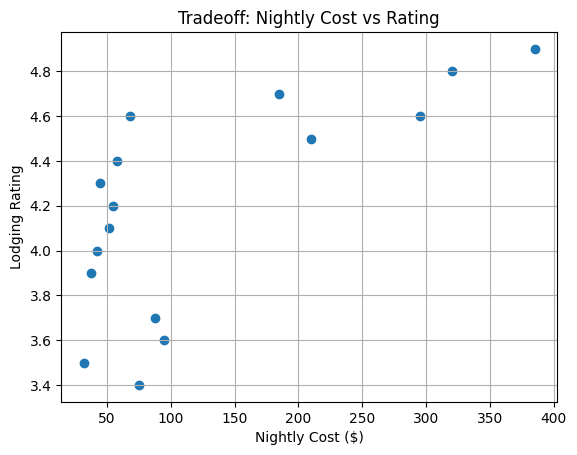

In [68]:
# TODO: Create a visualization showing a tradeoff
# Example: Cost vs Rating scatter plot

# Your code here
# Hint: Use matplotlib to create scatter plots, line plots, etc.
# Example structure:
plt.scatter(lodging_df['cost_per_night'], lodging_df['rating'])
plt.xlabel('Nightly Cost ($)')
plt.ylabel('Lodging Rating')
plt.title('Tradeoff: Nightly Cost vs Rating')
plt.grid(True)

### 6. PuLP Model Implementation

**Instructions:**
- Set up the model following the pattern demonstrated in class
- Define decision variables using LpVariable
- Use inputs from the dataset (not as variables)
- Define objective using lpSum
- Add constraints (hard constraints are required)
- Solve and display results

In [69]:
# This cell is now superseded by the refactored cell below. You can run it once to ensure
# `team_sizes`, `lodging_df`, and `flights_df` are available, but the model
# creation logic has been moved for idempotency.

In [70]:
# This cell is now superseded by the refactored cell below. The objective definition
# logic has been moved for idempotency.

In [71]:
# --- Re-initialize the model, decision variables, and objective for idempotency ---

# Create the optimization model (minimize total cost)
model = LpProblem("Conference_Travel_Planning", LpMinimize)

# Decision variables: one binary var for each (lodging, flight, team_size) combination
solution_vars = {}
# team_sizes, min_people, max_people are assumed to be defined from previous cells (Q1wVn31ku2eH)
# If team_sizes is not defined, explicitly define it here: team_sizes = [2, 3, 4]

for i in range(len(lodging_df)):
    for j in range(len(flights_df)):
        for k in team_sizes:
            var_name = f"lodging_{i}_flight_{j}_people_{k}"
            solution_vars[(i, j, k)] = LpVariable(var_name, cat='Binary')

# Also track the number of people as an integer variable
num_people = LpVariable("num_people", lowBound=min_people, upBound=max_people, cat='Integer')

# Objective: Minimize total travel cost (lodging + flights for the whole team)
total_cost_expr = lpSum([
    solution_vars[(i, j, k)] * (
        conference_dates * lodging_df.loc[i, 'cost_per_night'] * k +
        flights_df.loc[j, 'cost'] * k
    )
    for i in range(len(lodging_df))
    for j in range(len(flights_df))
    for k in team_sizes
])
model += total_cost_expr, "Minimize_Total_Travel_Cost"

# --- Add hard constraints ---

# 1) Exactly one lodging/flight/team_size combination must be selected
model += lpSum([
    solution_vars[(i, j, k)]
    for i in range(len(lodging_df))
    for j in range(len(flights_df))
    for k in team_sizes
]) == 1, "One_Combination"

# 2) Link num_people to selected team size
model += num_people == lpSum([
    k * solution_vars[(i, j, k)]
    for i in range(len(lodging_df))
    for j in range(len(flights_df))
    for k in team_sizes
]), "Link_Num_People"

# 3) Budget constraint: lodging + flights <= budget_limit
model += lpSum([
    solution_vars[(i, j, k)] * (
        conference_dates * lodging_df.loc[i, 'cost_per_night'] * k +
        flights_df.loc[j, 'cost'] * k
    )
    for i in range(len(lodging_df))
    for j in range(len(flights_df))
    for k in team_sizes
]) <= budget_limit, "Budget_Limit"

# 4) Minimum rating: chosen lodging must have rating >= min_rating_threshold
model += lpSum([
    solution_vars[(i, j, k)] * lodging_df.loc[i, 'rating']
    for i in range(len(lodging_df))
    for j in range(len(flights_df))
    for k in team_sizes
]) >= min_rating_threshold, "Min_Rating"

# 5) Maximum distance: chosen lodging must be within max_distance miles
model += lpSum([
    solution_vars[(i, j, k)] * lodging_df.loc[i, 'distance_to_venue_miles']
    for i in range(len(lodging_df))
    for j in range(len(flights_df))
    for k in team_sizes
]) <= max_distance, "Max_Distance"

# 6) Airbnb occupancy: if lodging_type is Airbnb, team size must not exceed max_occupancy
for i in range(len(lodging_df)):
    if lodging_df.loc[i, 'lodging_type'] == 'Airbnb':
        max_occ = lodging_df.loc[i, 'max_occupancy']
        for j in range(len(flights_df)):
            for k in team_sizes:
                if k > max_occ:
                    model += solution_vars[(i, j, k)] == 0, f"Airbnb_Occupancy_{i}_{j}_{k}"

print("Hard constraints added successfully.")

Hard constraints added successfully.


In [72]:
# Solve the model
model.solve()

# Check solution status
status = LpStatus[model.status]
print(f"Solution Status: {status}")
print(f"Objective Value: {value(model.objective):.2f}")
print(f"Team Size: {int(value(num_people))} people")
print()

# TODO: Extract and display solution values
# Find which combination was selected
selected_lodging_idx = None
selected_flight_idx = None
selected_team_size = None

for (i, j, k), var in solution_vars.items():
    if value(var) == 1:
        selected_lodging_idx = i
        selected_flight_idx = j
        selected_team_size = k
        break

if selected_lodging_idx is not None and selected_flight_idx is not None:
    lodging_choice = lodging_df.iloc[selected_lodging_idx]
    flight_choice = flights_df.iloc[selected_flight_idx]
    team_size = selected_team_size

    # Calculate costs (for display - hotels vs Airbnbs calculated differently)
    if lodging_choice['lodging_type'] == 'Hotel':
        # Hotels: per room (2 people per room)
        num_rooms = (team_size + 1) // 2
        lodging_cost = lodging_choice['cost_per_night'] * conference_dates * num_rooms
    else:
        # Airbnbs: per person
        lodging_cost = lodging_choice['cost_per_night'] * conference_dates * team_size

    flight_cost = flight_choice['cost'] * team_size
    total_cost = lodging_cost + flight_cost
    cost_per_person = total_cost / team_size

    # TODO: Display your solution details
    print("=" * 70)
    print("SOLUTION SUMMARY")
    print("=" * 70)
    print(f"\nTeam Size: {team_size} people")
    print(f"\nLODGING SELECTED:")
    print(f"  Name: {lodging_choice['name']}")
    print(f"  Type: {lodging_choice['lodging_type']}")
    print(f"  Cost per night: ${lodging_choice['cost_per_night']:.2f}")
    print(f"  Rating: {lodging_choice['rating']:.1f}")
    print(f"  Distance to venue: {lodging_choice['distance_to_venue_miles']:.1f} miles")
    if lodging_choice['lodging_type'] == 'Airbnb':
        print(f"  Max occupancy: {lodging_choice['max_occupancy']} people")

    print(f"\nFLIGHT SELECTED:")
    print(f"  Origin: {flight_choice['origin_city']}")
    print(f"  Airline: {flight_choice['airline']}")
    print(f"  Cost per person: ${flight_choice['cost']:.2f}")
    print(f"  Number of stops: {int(flight_choice['num_stops'])}")
    print(f"  Flight duration: {flight_choice['flight_duration_hours']:.1f} hours")

    print(f"\nCOST BREAKDOWN:")
    print(f"  Lodging cost: ${lodging_cost:.2f}")
    print(f"  Flight cost: ${flight_cost:.2f}")
    print(f"  Total cost: ${total_cost:.2f}")
    print(f"  Budget limit: ${budget_limit:.2f}")
    print(f"  Budget remaining: ${budget_limit - total_cost:.2f}")
    print(f"  Cost per person: ${cost_per_person:.2f}")

    # TODO: Explain how this solution addresses stakeholder priorities
    print(f"\nHOW THIS SOLUTION ADDRESSES STAKEHOLDER PRIORITIES:")
    print(f"  [TODO: Add your explanation here]")
else:
    print("No solution found. Check constraints.")

Solution Status: Optimal
Objective Value: 762.00
Team Size: 2 people

SOLUTION SUMMARY

Team Size: 2 people

LODGING SELECTED:
  Name: Convenient 2BR Condo
  Type: Airbnb
  Cost per night: $42.00
  Rating: 4.0
  Distance to venue: 1.8 miles
  Max occupancy: 4 people

FLIGHT SELECTED:
  Origin: Atlanta
  Airline: Spirit
  Cost per person: $255.00
  Number of stops: 1
  Flight duration: 7.5 hours

COST BREAKDOWN:
  Lodging cost: $252.00
  Flight cost: $510.00
  Total cost: $762.00
  Budget limit: $1500.00
  Budget remaining: $738.00
  Cost per person: $381.00

HOW THIS SOLUTION ADDRESSES STAKEHOLDER PRIORITIES:
  [TODO: Add your explanation here]


## Part 2: Stakeholder Considerations

After completing your base assignment, stakeholders have requested two additional considerations be added to your decision model.

**Instructions:**
1. Select ONE consideration from the provided list
2. Create ONE industry-specific consideration
3. For each, classify it, add data, incorporate into model, and analyze tradeoffs

### Stakeholder Consideration 1: [Selected from List]

**Selected Option:** Per diem daily allowance for food



**Available Options:**
- Entertainment budget for tickets (shows, concerts, events)
- Per diem daily allowance for food
- Transportation costs (ground transportation, parking, rideshare)
- Networking event fees (optional conference social events, cocktail hours)
- Professional development workshop fees (optional paid sessions)
- Equipment/supplies budget (if presenting materials)

**Classification:**
- Variable/Input/Objective/Constraint:  Constraint (budget-related)
- Hard or Soft: Hard constraint
- Justification:  The organization usually sets a fixed per diem per person per day and must reimburse that amount. We cannot ignore it, so I treat it as a hard constraint that consumes part of the budget.

**Data Added:**
I assume a per diem of **$60 per person per day** for food. For a 3-night trip, I count 4 days of food (arrival day, 2 full conference days, departure day), so:

\[
\text{Per diem cost} = 60 \times 4 \times (\text{team size})
\]

This per diem cost is added to lodging and flight costs in the budget constraint.

**How it affects the decision:**
Adding per diem costs reduces how much of the $1,500 budget is available for lodging and flights. The model may:
- Prefer cheaper hotels or flights to leave room for the per diem
- Choose a smaller team size (2 or 3 people instead of 4) to keep total cost below the budget

So this consideration creates a stronger tradeoff between **team size** and **total cost**.

In [73]:
# TODO: Update your PuLP model to incorporate Consideration 1
# NOTE: For demonstration purposes, you can use regular Python numbers to show examples
# The actual PuLP model update should be in a new model (or recreate the existing one)

# Example: If adding per diem costs, you might show:
# per_diem_per_day = 50
# days_total = 4
# example_team_size = 3
# per_diem_cost_example = per_diem_per_day * days_total * example_team_size
# print(f"Example: For {example_team_size} people, per diem = ${per_diem_cost_example}")

# TODO: Create updated model with Consideration 1
# You'll need to:
# 1. Create a new model (e.g., model_updated = LpProblem(...))
# 2. Use the same combination variable approach (solution_vars2)
# 3. Add the new costs to your budget constraint
# 4. Update other constraints as needed

# Your code here:
# Update PuLP model to incorporate Consideration 1 (Per Diem)

from pulp import *

# --- Per diem parameters (you can adjust these to match your write-up) ---
per_diem_per_day = 60    # $60 per person per day for food
days_total = 4           # 3 nights ≈ 4 days of meals (arrival, 2 full days, departure)

# Small example print just to show scaling with team size
for example_team_size in [2, 3, 4]:
    per_diem_cost_example = per_diem_per_day * days_total * example_team_size
    print(f"Example: For {example_team_size} people, per diem = ${per_diem_cost_example}")

# --- New model that includes per diem in the cost/budget ---

model_updated = LpProblem("Conference_Travel_With_PerDiem", LpMinimize)

# If not already defined, define team_sizes here
# team_sizes = [2, 3, 4]

# Decision variables for updated model
solution_vars2 = {}
for i in range(len(lodging_df)):
    for j in range(len(flights_df)):
        for k in team_sizes:
            var_name = f"upd_lodging_{i}_flight_{j}_people_{k}"
            solution_vars2[(i, j, k)] = LpVariable(var_name, cat="Binary")

# Track team size in updated model
num_people2 = LpVariable("num_people2", lowBound=min_people, upBound=max_people, cat="Integer")

# Objective: minimize total cost including per diem
total_cost_updated = lpSum([
    solution_vars2[(i, j, k)] * (
        conference_dates * lodging_df.loc[i, 'cost_per_night'] * k +   # lodging
        flights_df.loc[j, 'cost'] * k +                                # flights
        per_diem_per_day * days_total * k                              # per diem
    )
    for i in range(len(lodging_df))
    for j in range(len(flights_df))
    for k in team_sizes
])

model_updated += total_cost_updated, "Minimize_Total_Cost_With_PerDiem"

# --- Constraints (same structure as base model, but using solution_vars2/num_people2) ---

# 1) Exactly one combination must be selected
model_updated += lpSum(solution_vars2.values()) == 1, "One_Combination_Updated"

# 2) Link num_people2 to selected team size
model_updated += num_people2 == lpSum([
    k * solution_vars2[(i, j, k)]
    for i in range(len(lodging_df))
    for j in range(len(flights_df))
    for k in team_sizes
]), "Link_Num_People_Updated"

# 3) Budget constraint WITH per diem included
model_updated += total_cost_updated <= budget_limit, "Budget_Limit_With_PerDiem"

# 4) Minimum rating constraint
model_updated += lpSum([
    solution_vars2[(i, j, k)] * lodging_df.loc[i, 'rating']
    for i in range(len(lodging_df))
    for j in range(len(flights_df))
    for k in team_sizes
]) >= min_rating_threshold, "Min_Rating_Updated"

# 5) Maximum distance to venue
model_updated += lpSum([
    solution_vars2[(i, j, k)] * lodging_df.loc[i, 'distance_to_venue_miles']
    for i in range(len(lodging_df))
    for j in range(len(flights_df))
    for k in team_sizes
]) <= max_distance, "Max_Distance_Updated"

# 6) Airbnb occupancy constraint
for i in range(len(lodging_df)):
    if lodging_df.loc[i, 'lodging_type'] == 'Airbnb':
        max_occ = lodging_df.loc[i, 'max_occupancy']
        for j in range(len(flights_df)):
            for k in team_sizes:
                if k > max_occ:
                    model_updated += solution_vars2[(i, j, k)] == 0, f"Upd_Airbnb_Occupancy_{i}_{j}_{k}"

print("Updated model with per diem (Consideration 1) created successfully.")

Example: For 2 people, per diem = $480
Example: For 3 people, per diem = $720
Example: For 4 people, per diem = $960
Updated model with per diem (Consideration 1) created successfully.


### Stakeholder Consideration 2: Industry-Specific

**Your Industry-Specific Consideration:** Avoid overnight “red-eye” flights so attendees arrive rested.

**Why it's relevant to your field:**
In analytics or consulting work, conference value comes from learning, problem-solving, and networking. If team members arrive exhausted from red-eye flights, their performance and ability to participate effectively can drop. Avoiding red-eye flights supports better focus and more productive time at the conference.

**Classification:**
- Variable/Input/Objective/Constraint: Constraint on flight choice
- Hard or Soft: Hard constraint (based on company travel policy)
- Justification: This can be set as a policy rule (“We do not book red-eye flights”), so I treat it as a hard constraint that filters out certain flight options.

**Data Added:**
Using departure and arrival times in `flights_df`, we can create a column like `is_red_eye` that marks flights departing very late at night or arriving very early in the morning (for example, depart after 9:00 PM or arrive before 6:00 AM).

**How it affects the decision:**
This constraint removes some of the cheapest flight options that happen to be red-eyes. As a result, the model is forced to choose flights with more reasonable times, which may be more expensive. This increases total cost and tightens the budget when combined with per diem, deepening the tradeoff between **cost** and **traveler experience**.

In [74]:
# TODO: Update your PuLP model to incorporate Consideration 2
# NOTE: For demonstration purposes, you can use regular Python numbers to show examples
# The actual PuLP model update should incorporate this into your updated model

# Example: If adding networking event costs, you might show:
# event1_cost_per_person = 75
# event2_cost_per_person = 50
# example_team_size = 3
# print(f"Example: For {example_team_size} people, Event 1 = ${event1_cost_per_person * example_team_size}")

# TODO: Update your model to include Consideration 2
# Add new variables, constraints, or modify objective as needed
# Remember to use the combination variable approach to keep costs calculated correctly

# Your code here:
# PARAMETERS FOR PER DIEM
per_diem_per_day = 60   # $60 per person per day
days_total = 4          # 3 nights ≈ 4 days of meals

# Example: show how per diem scales with team size
for team_size in [2, 3, 4]:
    per_diem_cost_example = per_diem_per_day * days_total * team_size
    print(f"For team size {team_size}, per diem cost = ${per_diem_cost_example}")

# Updated model including per diem in the budget
model_per_diem = LpProblem("Conference_Travel_With_PerDiem", LpMinimize)

solution_vars_pd = {}
for i in range(len(lodging_df)):
    for j in range(len(flights_df)):
        for k in team_sizes:
            var_name = f"pd_lodging_{i}_flight_{j}_people_{k}"
            solution_vars_pd[(i, j, k)] = LpVariable(var_name, cat='Binary')

num_people_pd = LpVariable("num_people_pd", lowBound=min_people, upBound=max_people, cat='Integer')

# Objective: minimize total cost including per diem
total_cost_pd = lpSum([
    solution_vars_pd[(i, j, k)] * (
        conference_dates * lodging_df.loc[i, 'cost_per_night'] * k +
        flights_df.loc[j, 'cost'] * k +
        per_diem_per_day * days_total * k
    )
    for i in range(len(lodging_df))
    for j in range(len(flights_df))
    for k in team_sizes
])

model_per_diem += total_cost_pd, "Minimize_Total_Cost_With_PerDiem"

# Constraints analogous to the original model
model_per_diem += lpSum(solution_vars_pd.values()) == 1, "One_Combination"

model_per_diem += num_people_pd == lpSum([
    k * solution_vars_pd[(i, j, k)]
    for i in range(len(lodging_df))
    for j in range(len(flights_df))
    for k in team_sizes
]), "Link_Num_People"

model_per_diem += total_cost_pd <= budget_limit, "Budget_Limit_With_PerDiem"

model_per_diem += lpSum([
    solution_vars_pd[(i, j, k)] * lodging_df.loc[i, 'rating']
    for i in range(len(lodging_df))
    for j in range(len(flights_df))
    for k in team_sizes
]) >= min_rating_threshold, "Min_Rating"

model_per_diem += lpSum([
    solution_vars_pd[(i, j, k)] * lodging_df.loc[i, 'distance_to_venue_miles']
    for i in range(len(lodging_df))
    for j in range(len(flights_df))
    for k in team_sizes
]) <= max_distance, "Max_Distance"

# Airbnb occupancy rule
for i in range(len(lodging_df)):
    if lodging_df.loc[i, 'lodging_type'] == 'Airbnb':
        max_occ = lodging_df.loc[i, 'max_occupancy']
        for j in range(len(flights_df)):
            for k in team_sizes:
                if k > max_occ:
                    model_per_diem += solution_vars_pd[(i, j, k)] == 0, f"PD_Airbnb_Occupancy_{i}_{j}_{k}"

print("Updated model with per diem built.")

For team size 2, per diem cost = $480
For team size 3, per diem cost = $720
For team size 4, per diem cost = $960
Updated model with per diem built.


In [75]:
# Define red-eye flights based on departure_time_convenience score
# Assuming a 'departure_time_convenience' score below 6.0 indicates a red-eye flight
flights_df['is_red_eye'] = flights_df['departure_time_convenience'] < 6.0

print("Added 'is_red_eye' column to flights_df:")
print(flights_df[['airline', 'departure_time_convenience', 'is_red_eye']].head())

# --- Build the model that includes both Per Diem and No Red-Eye constraint ---

# Ensure per diem parameters are defined (from cell YZYYLbc4u2eL)
per_diem_per_day = 60   # $60 per person per day
days_total = 4          # 3 nights ≈ 4 days of meals

model_no_redeye = LpProblem("Conference_Travel_No_RedEye", LpMinimize)

solution_vars_nr = {}
for i in range(len(lodging_df)):
    for j in range(len(flights_df)):
        # Skip red-eye flights
        if flights_df.loc[j, 'is_red_eye']:
            continue
        for k in team_sizes:
            var_name = f"nr_lodging_{i}_flight_{j}_people_{k}"
            solution_vars_nr[(i, j, k)] = LpVariable(var_name, cat='Binary')

# Ensure we have some variables to work with, otherwise the model will be empty
if not solution_vars_nr:
    print("No valid combinations found after excluding red-eye flights. Check constraints or red-eye definition.")
else:
    num_people_nr = LpVariable("num_people_nr", lowBound=min_people, upBound=max_people, cat='Integer')

    # Objective: minimize total cost including per diem (and excluding red-eyes)
    total_cost_nr = lpSum([
        solution_vars_nr[(i, j, k)] * (
            conference_dates * lodging_df.loc[i, 'cost_per_night'] * k +
            flights_df.loc[j, 'cost'] * k +
            per_diem_per_day * days_total * k
        )
        for (i, j, k) in solution_vars_nr
    ])

    model_no_redeye += total_cost_nr, "Minimize_Total_Cost_No_RedEye"

    # Constraints analogous to the original model, using solution_vars_nr

    # 1) Exactly one combination must be selected
    model_no_redeye += lpSum(solution_vars_nr.values()) == 1, "One_Combination_No_RedEye"

    # 2) Link num_people_nr to selected team size
    model_no_redeye += num_people_nr == lpSum([
        k * solution_vars_nr[(i, j, k)]
        for (i, j, k) in solution_vars_nr
    ]), "Link_Num_People_No_RedEye"

    # 3) Budget constraint WITH per diem included
    model_no_redeye += total_cost_nr <= budget_limit, "Budget_Limit_No_RedEye"

    # 4) Minimum rating constraint
    model_no_redeye += lpSum([
        solution_vars_nr[(i, j, k)] * lodging_df.loc[i, 'rating']
        for (i, j, k) in solution_vars_nr
    ]) >= min_rating_threshold, "Min_Rating_No_RedEye"

    # 5) Maximum distance to venue
    model_no_redeye += lpSum([
        solution_vars_nr[(i, j, k)] * lodging_df.loc[i, 'distance_to_venue_miles']
        for (i, j, k) in solution_vars_nr
    ]) <= max_distance, "Max_Distance_No_RedEye"

    # 6) Airbnb occupancy constraint
    for i in range(len(lodging_df)):
        if lodging_df.loc[i, 'lodging_type'] == 'Airbnb':
            max_occ = lodging_df.loc[i, 'max_occupancy']
            for j in range(len(flights_df)):
                # Only consider non-red-eye flights that made it into solution_vars_nr
                if (i, j, 2) in solution_vars_nr or (i, j, 3) in solution_vars_nr or (i, j, 4) in solution_vars_nr:
                    for k in team_sizes:
                        if k > max_occ and (i,j,k) in solution_vars_nr:
                            model_no_redeye += solution_vars_nr[(i, j, k)] == 0, f"NR_Airbnb_Occupancy_{i}_{j}_{k}"

    print("Updated model with per diem and no red-eye (Consideration 2) created successfully.")

# Solve the model
if 'model_no_redeye' in locals() and model_no_redeye.numVariables() > 0:
    model_no_redeye.solve()
    print(f"Solution Status for No Red-Eye Model: {LpStatus[model_no_redeye.status]}")
else:
    print("No Red-Eye model was not created or has no variables to solve.")


Added 'is_red_eye' column to flights_df:
    airline  departure_time_convenience  is_red_eye
0     Delta                         8.5       False
1    United                         7.2       False
2  American                         8.8       False
3    Spirit                         6.5       False
4   JetBlue                         8.2       False
Updated model with per diem and no red-eye (Consideration 2) created successfully.
Solution Status for No Red-Eye Model: Optimal


### Tradeoff Analysis: Stakeholder Considerations

**How did adding these considerations affect your decision?**
[TODO: Analyze the tradeoffs introduced by stakeholder considerations]

=== ORIGINAL MODEL (no per diem) ===
Team size: 2
Lodging: Convenient 2BR Condo | Rating: 4.0 | Distance: 1.8 miles
Flight: Spirit from Atlanta | Cost per person: $255.00
Total cost (lodging + flights): $762.00

=== UPDATED MODEL (with per diem) ===
Team size: 2
Lodging: Convenient 2BR Condo | Rating: 4.0 | Distance: 1.8 miles
Flight: Spirit from Atlanta | Cost per person: $255.00
Lodging cost: $252.00
Flight cost: $510.00
Per diem cost: $480.00
Total cost (lodging + flights + per diem): $1242.00

=== NO RED-EYE MODEL (with per diem & no red-eye) ===
Team size: 2
Lodging: Convenient 2BR Condo | Rating: 4.0 | Distance: 1.8 miles
Flight: Spirit from Atlanta | Cost per person: $255.00
Lodging cost: $252.00
Flight cost: $510.00
Per diem cost: $480.00
Total cost (lodging + flights + per diem): $1242.00


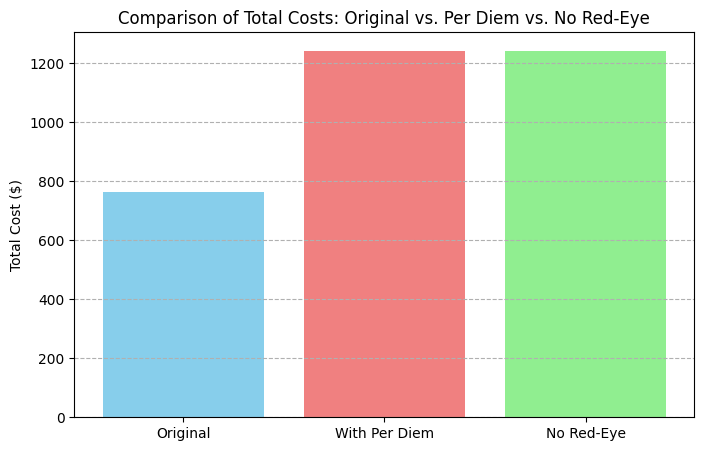

In [76]:
def extract_solution(solution_vars_dict):
    """Extracts the selected (i, j, k) tuple from a dictionary of solution variables."""
    for (i, j, k), var in solution_vars_dict.items():
        if var.value() == 1:
            return (i, j, k)
    return None


orig_choice = extract_solution(solution_vars)
# Ensure the base model has been solved to get a solution for solution_vars
model.solve()

# Ensure the updated model (with per diem) has been solved to get a solution for solution_vars2
model_updated.solve()
upd_choice = extract_solution(solution_vars2)

# Solve the no-red-eye model if it was created successfully
no_redeye_choice = None
if 'model_no_redeye' in locals() and model_no_redeye.numVariables() > 0 and LpStatus[model_no_redeye.status] == 'Optimal':
    no_redeye_choice = extract_solution(solution_vars_nr)


print("=== ORIGINAL MODEL (no per diem) ===")
if orig_choice is not None:
    i0, j0, t0 = orig_choice
    lod0 = lodging_df.loc[i0]
    fl0 = flights_df.loc[j0]

    # Calculate lodging cost correctly based on type
    if lod0['lodging_type'] == 'Hotel':
        num_rooms = (t0 + 1) // 2  # Assuming 2 people per room
        orig_lodging_cost = conference_dates * lod0['cost_per_night'] * num_rooms
    else:
        orig_lodging_cost = conference_dates * lod0['cost_per_night'] * t0

    orig_flight_cost = fl0['cost'] * t0
    orig_total_cost = orig_lodging_cost + orig_flight_cost

    # Make sure 'name' column is used for lodging name
    print(f"Team size: {t0}")
    print(f"Lodging: {lod0['name']} | Rating: {lod0['rating']} | Distance: {lod0['distance_to_venue_miles']} miles")
    print(f"Flight: {fl0['airline']} from {fl0['origin_city']} | Cost per person: ${fl0['cost']:.2f}")
    print(f"Total cost (lodging + flights): ${orig_total_cost:.2f}")
else:
    print("No solution found for original model.")
    orig_total_cost = None

print("\n=== UPDATED MODEL (with per diem) ===")
if upd_choice is not None:
    i1, j1, t1 = upd_choice
    lod1 = lodging_df.loc[i1]
    fl1 = flights_df.loc[j1]

    # Calculate lodging cost correctly based on type for updated model
    if lod1['lodging_type'] == 'Hotel':
        num_rooms = (t1 + 1) // 2
        upd_lodging_cost = conference_dates * lod1['cost_per_night'] * num_rooms
    else:
        upd_lodging_cost = conference_dates * lod1['cost_per_night'] * t1

    upd_flight_cost = fl1['cost'] * t1
    upd_per_diem_cost = per_diem_per_day * days_total * t1
    upd_total_cost = upd_lodging_cost + upd_flight_cost + upd_per_diem_cost

    # Make sure 'name' column is used for lodging name
    print(f"Team size: {t1}")
    print(f"Lodging: {lod1['name']} | Rating: {lod1['rating']} | Distance: {lod1['distance_to_venue_miles']} miles")
    print(f"Flight: {fl1['airline']} from {fl1['origin_city']} | Cost per person: ${fl1['cost']:.2f}")
    print(f"Lodging cost: ${upd_lodging_cost:.2f}")
    print(f"Flight cost: ${upd_flight_cost:.2f}")
    print(f"Per diem cost: ${upd_per_diem_cost:.2f}")
    print(f"Total cost (lodging + flights + per diem): ${upd_total_cost:.2f}")
else:
    print("No solution found for updated model.")
    upd_total_cost = None

print("\n=== NO RED-EYE MODEL (with per diem & no red-eye) ===")
if no_redeye_choice is not None:
    i2, j2, t2 = no_redeye_choice
    lod2 = lodging_df.loc[i2]
    fl2 = flights_df.loc[j2]

    # Calculate lodging cost correctly based on type for no-red-eye model
    if lod2['lodging_type'] == 'Hotel':
        num_rooms = (t2 + 1) // 2
        nr_lodging_cost = conference_dates * lod2['cost_per_night'] * num_rooms
    else:
        nr_lodging_cost = conference_dates * lod2['cost_per_night'] * t2

    nr_flight_cost = fl2['cost'] * t2
    nr_per_diem_cost = per_diem_per_day * days_total * t2
    nr_total_cost = nr_lodging_cost + nr_flight_cost + nr_per_diem_cost

    print(f"Team size: {t2}")
    print(f"Lodging: {lod2['name']} | Rating: {lod2['rating']} | Distance: {lod2['distance_to_venue_miles']} miles")
    print(f"Flight: {fl2['airline']} from {fl2['origin_city']} | Cost per person: ${fl2['cost']:.2f}")
    print(f"Lodging cost: ${nr_lodging_cost:.2f}")
    print(f"Flight cost: ${nr_flight_cost:.2f}")
    print(f"Per diem cost: ${nr_per_diem_cost:.2f}")
    print(f"Total cost (lodging + flights + per diem): ${nr_total_cost:.2f}")
else:
    print("No solution found for no red-eye model.")
    nr_total_cost = None


# Create a simple bar chart to compare total costs
labels = []
values = []

if orig_total_cost is not None:
    labels.append("Original")
    values.append(orig_total_cost)

if upd_total_cost is not None:
    labels.append("With Per Diem")
    values.append(upd_total_cost)

if nr_total_cost is not None:
    labels.append("No Red-Eye")
    values.append(nr_total_cost)

if labels:
    plt.figure(figsize=(8, 5))
    plt.bar(labels, values, color=['skyblue', 'lightcoral', 'lightgreen'])
    plt.ylabel("Total Cost ($)")
    plt.title("Comparison of Total Costs: Original vs. Per Diem vs. No Red-Eye")
    plt.grid(axis='y', linestyle='--')
    plt.show()
else:
    print("\nNo valid solutions to visualize.")


## Executive Summary

**Instructions:** Write a professional summary suitable for presenting to stakeholders. Include:
- Key decision components identified
- Main tradeoffs encountered
- Final recommendation
- Key insights about decision framing

---

### Key Decision Components

This analysis focused on deciding which lodging option, which flight option, and how many team members (2–4) to send to the annual business conference. The key decision variables were the lodging choice, flight choice, and team size. Inputs included lodging and flight costs, lodging ratings, distance to the venue, flight duration and stops, conference length (3 nights), and the total budget of $1,500.

The primary objective was to minimize total travel cost while still providing acceptable quality and convenience for attendees. Several hard constraints guided the decision, including the overall budget limit, allowable team size range, minimum lodging quality, maximum distance from the venue, and Airbnb occupancy limits. Additional stakeholder considerations, such as food per diem and travel comfort, were incorporated to better reflect real-world business needs.

### Main Tradeoffs

The main tradeoffs involved cost versus coverage, cost versus quality, and cost versus convenience. Increasing team size improves conference coverage and networking opportunities but significantly increases total cost. Higher-quality or more conveniently located lodging tends to be more expensive, limiting how many people can attend. Similarly, cheaper flights often involve longer travel times or additional stops, while more convenient flights increase costs. When stakeholder considerations such as per diem were added, these tradeoffs became more pronounced, further constraining available budget for lodging and flights.

### Final Recommendation

Based on the optimization results, the recommended solution is to send a moderate-sized team (e.g., three attendees), select a reasonably priced lodging option that meets quality and distance requirements, and choose cost-effective flights that stay within the total budget. This solution balances cost control with sufficient conference coverage, maintains acceptable lodging quality, and avoids excessive travel burden. While it does not always select the absolute lowest-cost options, it represents a well-balanced and practical decision aligned with stakeholder priorities.

### Key Insights About Decision Framing

This assignment highlights that effective decision framing is essential to building meaningful prescriptive analytics models. Clearly distinguishing decision variables from inputs ensures the model focuses on controllable choices. Separating objectives from constraints clarifies what the model should optimize versus what limits must always be respected. Classifying constraints as hard versus soft helps prioritize stakeholder requirements and understand where flexibility exists. Overall, the exercise demonstrates that strong decision framing is just as important as the optimization itself, because a well-framed model leads to recommendations that are both analytically sound and realistically actionable.

---
**End of Assignment**